#1.Data Loading and Preparation
Workflow: Load the airbnb.xlsx - AirBnB_NYC.csv dataset. Convert the Host Since column to a proper datetime format. Analytical Question: In a markdown cell, explain what kind of new, valuable feature you could create from the Host Since column. How might this new feature help the model predict prices? Screenshot Requirement: Upload a screenshot showing your code, the .info() output confirming the new data type, and your markdown answer.

## Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from datetime import datetime


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load data
data = pd.read_excel("/content/airbnb.xlsx")
data.head(5)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0


In [ ]:
data.shape

(30475, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

In [ ]:
data.describe()


,Host Id,Host Since,Review Scores Rating (bin),Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
count,3.047500e+04,30475,22155.000000,30341.000000,30390.000000,30475.0,30475.000000,30475.000000,22155.000000
mean,1.273040e+07,2013-06-29 17:56:15.317473024,90.738659,10584.830691,1.530141,1.0,12.019852,163.598950,91.993230
min,5.000000e+02,2008-06-26 00:00:00,20.000000,1003.000000,0.000000,1.0,0.000000,10.000000,20.000000
25%,2.700193e+06,2012-06-21 00:00:00,85.000000,10017.000000,1.000000,1.0,0.000000,80.000000,89.000000
50%,8.551260e+06,2013-09-01 00:00:00,90.000000,10065.000000,1.000000,1.0,3.000000,125.000000,94.000000
75%,2.119605e+07,2014-09-12 00:00:00,100.000000,11216.000000,2.000000,1.0,13.000000,195.000000,100.000000
max,4.303307e+07,2015-08-31 00:00:00,100.000000,99135.000000,16.000000,1.0,257.000000,10000.000000,100.000000
std,1.190164e+07,NaN,9.059519,921.324686,1.015395,0.0,21.981496,197.792306,8.850373


In [ ]:
data.columns


Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')

In [ ]:
data.dtypes

,0
Host Id,int64
Host Since,datetime64[ns]
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [ ]:
#to identify the dataset's timeframe
print(f"Dataset Date Range:")
print(f"Earliest Host Since: {data['Host Since'].min()}")
print(f"Latest Host Since: {data['Host Since'].max()}")

Dataset Date Range:
Earliest Host Since: 2008-06-26 00:00:00
Latest Host Since: 2015-08-31 00:00:00


In [ ]:
# Determine the reference date (use the maximum date in the dataset)
reference_date = data['Host Since'].max()
print(f"Using reference date for calculations: {reference_date}")


Using reference date for calculations: 2015-08-31 00:00:00


In [ ]:
# Calculate years as a host (relative to the dataset's time period)
data['Years_as_Host'] = (reference_date - data['Host Since']).dt.days / 365.25

print(f"\nYears as Host - Statistics:")
print(data['Years_as_Host'].describe())


Years as Host - Statistics:
count    30475.000000
mean         2.169069
std          1.468385
min          0.000000
25%          0.966461
50%          1.995893
75%          3.192334
max          7.178645
Name: Years_as_Host, dtype: float64


In [ ]:
# Create categorical buckets based on the 2008-2015 timeframe

def categorize_host_experience(years):
    if years < 0.5:
        return 'Brand New Host'
    elif years < 1:
        return 'New Host'
    elif years < 2:
        return 'Emerging Host'
    elif years < 4:
        return 'Established Host'
    else:
        return 'Veteran Host'

data['Host_Experience_Level'] = data['Years_as_Host'].apply(categorize_host_experience)


In [ ]:
# Display the new features
print("\nNew Features Created (Sample of 15 rows):")
print(data[['Host Since', 'Years_as_Host', 'Host_Experience_Level']].head(15))


New Features Created (Sample of 15 rows):
   Host Since  Years_as_Host Host_Experience_Level
0  2008-06-26       7.178645          Veteran Host
1  2008-06-26       7.178645          Veteran Host
2  2008-07-25       7.099247          Veteran Host
3  2008-08-12       7.049966          Veteran Host
4  2008-08-15       7.041752          Veteran Host
5  2008-08-20       7.028063          Veteran Host
6  2008-08-20       7.028063          Veteran Host
7  2008-08-27       7.008898          Veteran Host
8  2008-09-06       6.981520          Veteran Host
9  2008-09-06       6.981520          Veteran Host
10 2008-09-07       6.978782          Veteran Host
11 2008-09-09       6.973306          Veteran Host
12 2008-09-10       6.970568          Veteran Host
13 2008-09-14       6.959617          Veteran Host
14 2008-09-25       6.929500          Veteran Host


In [ ]:
print("\nHost Experience Level Distribution:")
experience_dist = data['Host_Experience_Level'].value_counts().sort_index()
print(experience_dist)
print("\nPercentage Distribution:")
print(data['Host_Experience_Level'].value_counts(normalize=True).sort_index() * 100)



Host Experience Level Distribution:
Host_Experience_Level
Brand New Host       4173
Emerging Host        7335
Established Host    11405
New Host             3754
Veteran Host         3808
Name: count, dtype: int64

Percentage Distribution:
Host_Experience_Level
Brand New Host      13.693191
Emerging Host       24.068909
Established Host    37.424118
New Host            12.318294
Veteran Host        12.495488
Name: proportion, dtype: float64


In [ ]:
print("\nData Info After Feature Engineering:")
print(data.info())


Data Info After Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price           

In [ ]:
data['Host Since'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30475 entries, 0 to 30474
Series name: Host Since
Non-Null Count  Dtype         
--------------  -----         
30475 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 238.2 KB


## Analytical Question:
Created 2 new features - Years as Host & Host Experience Level (Dataset Period: 2008-2015)

The new feature might help

1. **Market Evolution Signal**
   - Early adopters may have different pricing strategies than later joiners
   - Captures when hosts entered a growing, less saturated market
   - Reflects access to prime locations claimed by early movers

2. **Network Effect & Price Momentum**
   - Veteran hosts established baselines that influence pricing
   - New hosts anchor their prices relative to market standards
   - Creates predictable price tiers by experience level



#2. Handling Missing Data
Workflow: The columns related to review scores have missing values. Decide on an appropriate imputation strategy to handle them. Analytical Question: In a markdown cell, justify your choice of imputation strategy for the Review Scores Rating column. Did you use the mean, median, or another value? Why was your choice appropriate for this column? Screenshot Requirement: Upload a screenshot showing your imputation code, the output of .isnull().sum() after imputation, and your markdown justification.

In [ ]:
#before handling missing values
data.isna().sum()

,0
Host Id,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


In [ ]:
missing_percent = data.isna().sum()/len(data)*100
missing_percent.sort_values(ascending=False)

,0
Review Scores Rating (bin),27.301066
Review Scores Rating,27.301066
Zipcode,0.439705
Beds,0.278917
Property Type,0.009844
Name,0.000000
Host Id,0.000000
Room Type,0.000000
Neighbourhood,0.000000
Host Since,0.000000


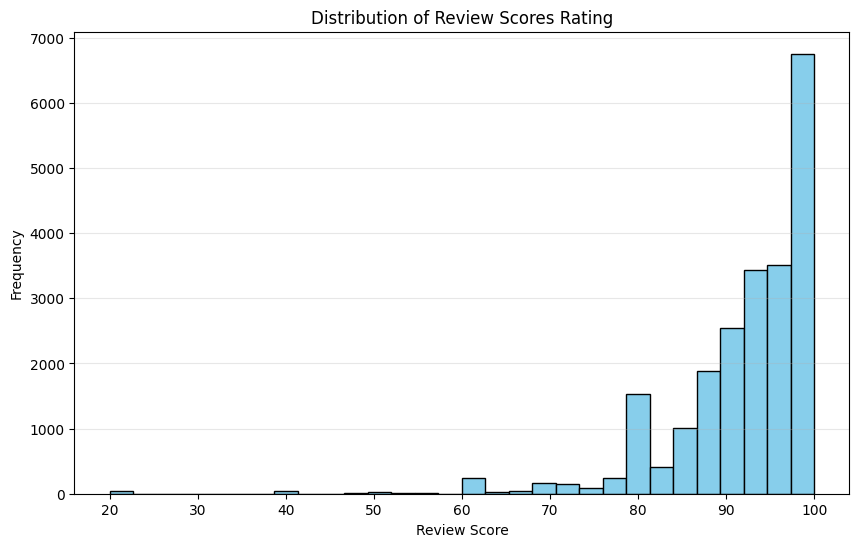

In [ ]:
# Create a simple histogram
plt.figure(figsize=(10, 6))
plt.hist(data['Review Scores Rating'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.title('Distribution of Review Scores Rating')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
data['Review Scores Rating'].fillna(data['Review Scores Rating'].median(), inplace=True)

In [ ]:
data['Review Scores Rating (bin)'].fillna(data['Review Scores Rating'].median(), inplace=True)

In [ ]:
zipcode_mode = data['Zipcode'].mode()[0]
data['Zipcode'].fillna(zipcode_mode, inplace=True)

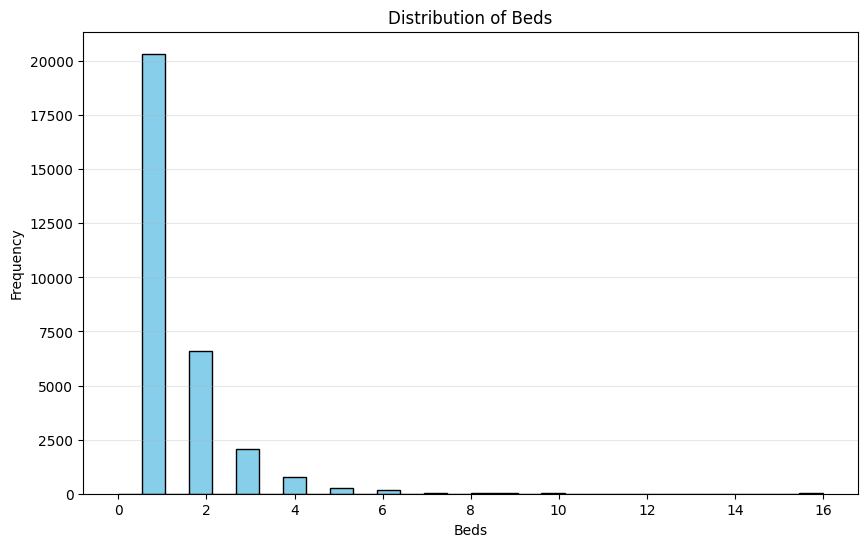

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['Beds'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Beds')
plt.ylabel('Frequency')
plt.title('Distribution of Beds')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
beds_median = data['Beds'].median()
data['Beds'].fillna(beds_median, inplace=True)

In [ ]:
property_mode = data['Property Type'].mode()[0]
data['Property Type'].fillna(property_mode, inplace=True)

In [ ]:
#after handling missing value
data.isna().sum()

,0
Host Id,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,0
Review Scores Rating (bin),0
Room Type,0
Zipcode,0
Beds,0
Number of Records,0


## 2. Analytical Question
The missing values of Review Scores Rating was handled with median since the graph of distribution showed a skewed distribution
Similarly Beds were filled with median value for the skewed distribution
Zipcode and Property code were replaced with mode

#3. Advanced Feature Engineering
Workflow: Engineer a new interaction feature by combining Neighbourhood and Room Type. Prepare two versions of your dataset for modeling: one without your new feature, and one with it. Train and evaluate a Random Forest Regressor on both datasets and compare their RMSE scores. Analytical Question: In a markdown cell, present the RMSE scores from both models. Did your new feature improve the model's performance? Explain why an interaction feature like this might capture more nuanced information. Screenshot Requirement: Upload a screenshot showing the code where you create the new feature, the two RMSE scores from your model evaluations, and your markdown answer explaining the impact.

In [ ]:
data = data.drop('Host Id', axis=1)

In [ ]:
# Create interaction feature: Neighbourhood_RoomType
data['Neighbourhood_RoomType'] = data['Neighbourhood '] + '_' + data['Room Type']

print(f"\n✓ Interaction Feature Created: 'Neighbourhood_RoomType'")
print(f"\nSample interactions:")
print(data[['Neighbourhood ', 'Room Type', 'Neighbourhood_RoomType']].head(10))
print(f"\nTotal unique combinations: {data['Neighbourhood_RoomType'].nunique()}")


✓ Interaction Feature Created: 'Neighbourhood_RoomType'

Sample interactions:
  Neighbourhood         Room Type     Neighbourhood_RoomType
0      Manhattan  Entire home/apt  Manhattan_Entire home/apt
1      Manhattan     Private room     Manhattan_Private room
2       Brooklyn  Entire home/apt   Brooklyn_Entire home/apt
3      Manhattan  Entire home/apt  Manhattan_Entire home/apt
4       Brooklyn     Private room      Brooklyn_Private room
5      Manhattan  Entire home/apt  Manhattan_Entire home/apt
6      Manhattan  Entire home/apt  Manhattan_Entire home/apt
7       Brooklyn  Entire home/apt   Brooklyn_Entire home/apt
8      Manhattan     Private room     Manhattan_Private room
9      Manhattan     Private room     Manhattan_Private room

Total unique combinations: 15


In [ ]:
# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

In [ ]:
# Remove target variable and unnecessary columns from feature lists
target = 'Price'
cols_to_remove_from_features = ['Price', 'Host Since', 'Last Review']  # Remove date columns

numerical_features = [col for col in numerical_cols if col not in cols_to_remove_from_features]
categorical_features = [col for col in categorical_cols if col not in cols_to_remove_from_features]

print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)

print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

print(f"\nTarget Variable: {target}")


Numerical Features (7):
['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Review Scores Rating', 'Years_as_Host']

Categorical Features (6):
['Name', 'Neighbourhood ', 'Property Type', 'Room Type', 'Host_Experience_Level', 'Neighbourhood_RoomType']

Target Variable: Price


In [ ]:
le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [ ]:
# VERSION 1: WITHOUT Interaction Feature
features_v1 = numerical_features + [col for col in categorical_features if col != 'Neighbourhood_RoomType']

X_v1 = data[features_v1]
y = data[target]

print(f"\nVersion 1 (WITHOUT Interaction Feature):")
print(f"Number of features: {len(features_v1)}")
print(f"Features: {features_v1}")
print(f"Shape: {X_v1.shape}")


Version 1 (WITHOUT Interaction Feature):
Number of features: 12
Features: ['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Review Scores Rating', 'Years_as_Host', 'Name', 'Neighbourhood ', 'Property Type', 'Room Type', 'Host_Experience_Level']
Shape: (30475, 12)


In [ ]:
# VERSION 2: WITH Interaction Feature
features_v2 = numerical_features + categorical_features

X_v2 = data[features_v2]
y = data[target]

print(f"\nVersion 2 (WITH Interaction Feature):")
print(f"Number of features: {len(features_v2)}")
print(f"Features: {features_v2}")
print(f"Shape: {X_v2.shape}")


Version 2 (WITH Interaction Feature):
Number of features: 13
Features: ['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Review Scores Rating', 'Years_as_Host', 'Name', 'Neighbourhood ', 'Property Type', 'Room Type', 'Host_Experience_Level', 'Neighbourhood_RoomType']
Shape: (30475, 13)


In [ ]:

# Use same random state for both versions to ensure same split
X_v1_train, X_v1_test, y_train, y_test = train_test_split(X_v1, y, test_size=0.2, random_state=42)
X_v2_train, X_v2_test, _, _ = train_test_split(X_v2, y, test_size=0.2, random_state=42)

In [ ]:
 #TRAIN RANDOM FOREST MODEL 1 (WITHOUT Interaction Feature)


print("\nTraining Random Forest Regressor (Model 1)...")
rf_model_v1 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2
)
rf_model_v1.fit(X_v1_train, y_train)

# Make predictions
y_pred_v1 = rf_model_v1.predict(X_v1_test)

# Calculate metrics
rmse_v1 = np.sqrt(mean_squared_error(y_test, y_pred_v1))
r2_v1 = r2_score(y_test, y_pred_v1)
mae_v1 = np.mean(np.abs(y_test - y_pred_v1))

print(f"\n✓ Model 1 Trained Successfully")
print(f"RMSE (Model 1): ${rmse_v1:.2f}")
print(f"R² Score (Model 1): {r2_v1:.4f}")
print(f"MAE (Model 1): ${mae_v1:.2f}")


Training Random Forest Regressor (Model 1)...

✓ Model 1 Trained Successfully
RMSE (Model 1): $150.30
R² Score (Model 1): 0.3338
MAE (Model 1): $55.65


In [ ]:
# TRAIN RANDOM FOREST MODEL 2 (WITH Interaction Feature)



print("\nTraining Random Forest Regressor (Model 2)...")
rf_model_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2
)
rf_model_v2.fit(X_v2_train, y_train)

# Make predictions
y_pred_v2 = rf_model_v2.predict(X_v2_test)

# Calculate metrics
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))
r2_v2 = r2_score(y_test, y_pred_v2)
mae_v2 = np.mean(np.abs(y_test - y_pred_v2))

print(f"\n✓ Model 2 Trained Successfully")
print(f"RMSE (Model 2): ${rmse_v2:.2f}")
print(f"R² Score (Model 2): {r2_v2:.4f}")
print(f"MAE (Model 2): ${mae_v2:.2f}")



Training Random Forest Regressor (Model 2)...

✓ Model 2 Trained Successfully
RMSE (Model 2): $150.31
R² Score (Model 2): 0.3337
MAE (Model 2): $55.62


In [ ]:
# COMPARE RESULTS

improvement = ((rmse_v1 - rmse_v2) / rmse_v1) * 100

print(f"\n{'Metric':<25} {'Model 1 (No Feature)':<25} {'Model 2 (With Feature)':<25} {'Difference':<20}")
print("="*95)
print(f"{'RMSE':<25} ${rmse_v1:<24.2f} ${rmse_v2:<24.2f} ${rmse_v1-rmse_v2:<19.2f}")
print(f"{'R² Score':<25} {r2_v1:<24.4f} {r2_v2:<24.4f} {r2_v2-r2_v1:<19.4f}")
print(f"{'MAE':<25} ${mae_v1:<24.2f} ${mae_v2:<24.2f} ${mae_v1-mae_v2:<19.2f}")
print("="*95)

print(f"\n{'RMSE Improvement:':<30} {improvement:.2f}%")

if rmse_v2 < rmse_v1:
    print(f"✓ The interaction feature IMPROVED model performance!")
    print(f"  RMSE decreased by ${rmse_v1 - rmse_v2:.2f}")
else:
    print(f"⚠ The interaction feature did NOT improve performance")
    print(f"  RMSE increased by ${rmse_v2 - rmse_v1:.2f}")


Metric                    Model 1 (No Feature)      Model 2 (With Feature)    Difference          
RMSE                      $150.30                   $150.31                   $-0.02              
R² Score                  0.3338                   0.3337                   -0.0001            
MAE                       $55.65                    $55.62                    $0.03               

RMSE Improvement:              -0.01%
⚠ The interaction feature did NOT improve performance
  RMSE increased by $0.02


## 3. Analytical Question - The interaction feature did not improve the performance. Also RMSE increased only by $0.02

#4. Final Model Training and Evaluation
Workflow: Using your best-performing dataset from the previous task, prepare the data, split it, train your final Random Forest Regressor, and evaluate its Root Mean Squared Error (RMSE). Analytical Question: In a markdown cell, explain what your final model's RMSE value means in practical terms. For example, if your RMSE is 50, what does that tell a host about the accuracy of the predicted price? Screenshot Requirement: Upload a screenshot showing the code for training and evaluation, the printed RMSE score, and your markdown interpretation.

In [ ]:

print("\nTraining final Random Forest Regressor...")

final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=2
)

final_model.fit(X_v2_train, y_train)


Training final Random Forest Regressor...


RandomForestRegressor(max_depth=8, min_samples_leaf=2, min_samples_split=10,
                      n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error

# Training set performance
y_pred_train = final_model.predict(X_v2_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Test set performance
y_pred_test = final_model.predict(X_v2_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"\n{'METRIC':<25} {'TRAINING SET':<20} {'TEST SET':<20}")
print("="*65)
print(f"{'RMSE':<25} ${rmse_train:<19.2f} ${rmse_test:<19.2f}")
print(f"{'R² Score':<25} {r2_train:<20.4f} {r2_test:<20.4f}")
print(f"{'MAE':<25} ${mae_train:<19.2f} ${mae_test:<19.2f}")
print("="*65)



METRIC                    TRAINING SET         TEST SET            
RMSE                      $151.92              $149.04             
R² Score                  0.4290               0.3449              
MAE                       $54.23               $55.87              


# Analytical Question 4:

## Simple RMSE Interpretation

### The Bottom Line
- **Model predicts within ±$149 of actual price**
- **92% error rate - too high for real use**
- **Only explains 34% of what drives prices**

### Examples
- Price $200? Model predicts $51-$349
- Price $162? Model predicts $13-$311


### How to Use
Use model prediction as starting point, then adjust manually based on market research.


In [ ]:
import pickle

# After training your final model, save it
pickle.dump(final_model, open('airbnb_price_model.pkl', 'wb'))
print("✓ Model saved as 'airbnb_price_model.pkl'")

# Also save the label encoders for categorical variables
pickle.dump(label_encoders, open('label_encoders.pkl', 'wb'))
print("✓ Label encoders saved as 'label_encoders.pkl'")

# Save feature names for reference
import json
feature_data = {
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'all_features': features_v2
}

with open('features.json', 'w') as f:
    json.dump(feature_data, f)
print("✓ Features saved as 'features.json'")

✓ Model saved as 'airbnb_price_model.pkl'
✓ Label encoders saved as 'label_encoders.pkl'
✓ Features saved as 'features.json'


#5. Flask Application Backend
Workflow: Save your trained model. Create the app.py to implement the backend prediction logic. Screenshot Requirement: showing the completed /predict function within app.py

#6. Flask Application Frontend
Workflow: Create the index.html file to create the user input form. Screenshot Requirement: Upload screenshots: showing the body section of your completed index.html.